# Milestone 2: Customer Segmentation

In this notebook, we perform customer segmentation using RFM features and clustering models (KMeans, GMM, UMAP + HDBSCAN).

In [1]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("../data/online_retail_cleaned.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceYearMonth,InvoiceWeek,InvoiceDay
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,48,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,48,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,48,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,48,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,48,2010-12-01


In [2]:
import datetime as dt

# Set reference date (last invoice + 1 day)
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Compute RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])


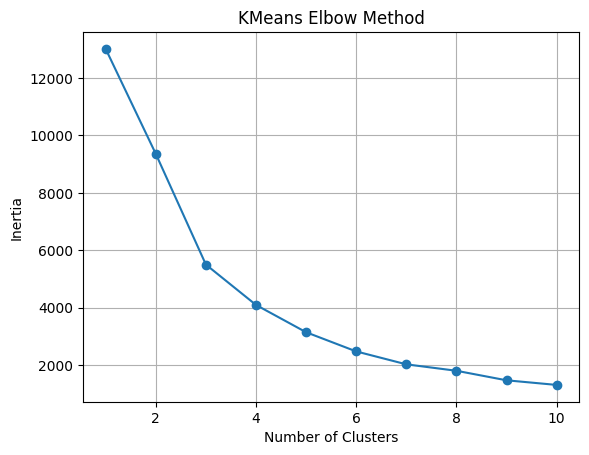

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('KMeans Elbow Method')
plt.grid()
plt.show()


In [5]:
from sklearn.metrics import silhouette_score

# Try KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(rfm_scaled)
rfm['Cluster_KMeans'] = labels_kmeans

score = silhouette_score(rfm_scaled, labels_kmeans)
print(f"Silhouette Score (KMeans, k=4): {score:.3f}")


Silhouette Score (KMeans, k=4): 0.616


In [6]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
labels_gmm = gmm.fit_predict(rfm_scaled)
rfm['Cluster_GMM'] = labels_gmm


In [7]:
import umap.umap_ as umap
import hdbscan

reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(rfm_scaled)

clusterer = hdbscan.HDBSCAN(min_cluster_size=20)
labels_hdbscan = clusterer.fit_predict(embedding)

rfm['Cluster_HDBSCAN'] = labels_hdbscan


/Users/Pi/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/Pi/miniconda3/envs/myenv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/Pi/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/Pi/miniconda3/envs/myenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


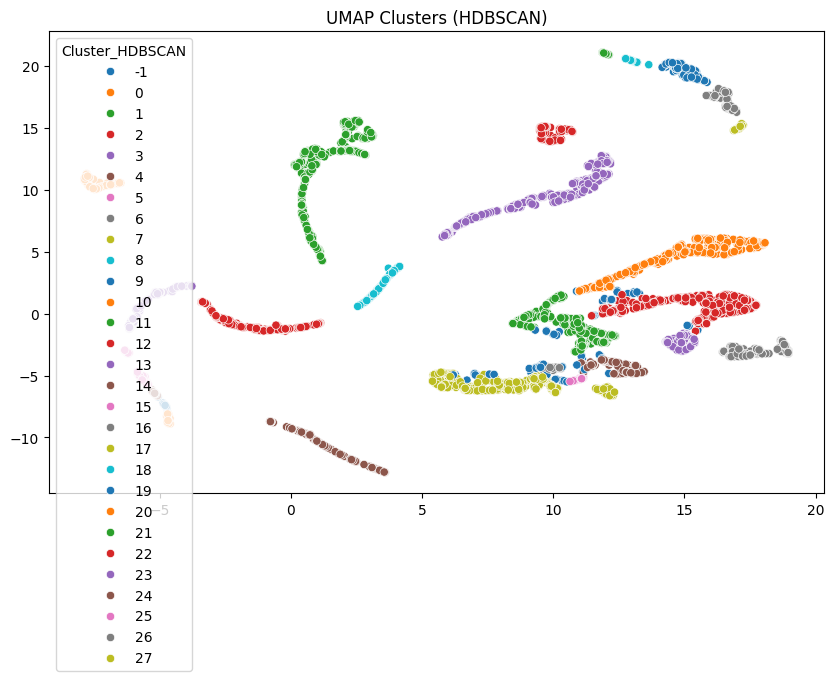

In [8]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(x=embedding[:,0], y=embedding[:,1], hue=rfm['Cluster_HDBSCAN'], palette='tab10')
plt.title("UMAP Clusters (HDBSCAN)")
plt.show()


In [9]:
# Save RFM with cluster labels
rfm.to_csv("../data/rfm_clustered.csv", index=False)
print("Clustered RFM dataset saved.")


Clustered RFM dataset saved.
